# Caracterización estadística del SPY

**Hechos estilizados de los retornos diarios del S&P 500 (ETF `SPY`, 1993–2025)**

Este notebook documenta la caracterización empírica de la serie de precios del SPY que sirve
como punto de partida de un trabajo de tesis en finanzas cuantitativas / econofísica. El objetivo
no es predecir, sino **establecer qué propiedades estadísticas debe respetar cualquier modelo**
que se ajuste después a esta serie.

Se verifican, uno por uno, los *stylized facts* clásicos de series financieras
(Mandelbrot 1963; Cont 2001):

| # | Hecho estilizado | Sección |
|---|------------------|---------|
| 1 | Crecimiento aproximadamente exponencial del precio | [2](#2-trayectoria-del-precio) |
| 2 | Colas pesadas y leptocurtosis de los retornos | [3](#3-distribución-de-retornos) |
| 3 | Asimetría negativa | [3](#3-distribución-de-retornos) |
| 4 | Incertidumbre de los momentos bajo dependencia serial | [4](#4-momentos-con-incertidumbre-moving-block-bootstrap) |
| 5 | Ausencia de autocorrelación lineal en los retornos | [5](#5-autocorrelación-retornos-vs-retornos-al-cuadrado) |
| 6 | Autocorrelación persistente en los retornos al cuadrado | [5](#5-autocorrelación-retornos-vs-retornos-al-cuadrado) |
| 7 | Clustering de volatilidad y regímenes | [6](#6-clustering-de-volatilidad-y-regímenes) |

---

### Datos

Precios de cierre **ajustados** (dividendos y splits) del ETF `SPY`, descargados con
[`yfinance`](https://github.com/ranaroussi/yfinance) desde el inicio de la serie (enero de 1993).
La descarga se cachea en `data/` para que las corridas posteriores sean reproducibles y offline.

### Cómo correrlo

```bash
pip install -r requirements.txt
jupyter lab SPY_caracterizacion.ipynb   # Kernel > Restart & Run All
```

> **Nota sobre la definición de retorno.** Salvo aclaración explícita, se trabaja con retornos
> logarítmicos $x_t = \log S_t - \log S_{t-1}$, que son aditivos en el tiempo. Para movimientos
> diarios la diferencia con el retorno simple $S_t/S_{t-1}-1$ es de segundo orden, y en la
> Sección 3 se muestran ambos para dejarlo documentado.

## 1. Configuración

Todos los parámetros del análisis viven en esta celda: cambiar el ticker, la ventana temporal o
el factor de anualización no requiere tocar ninguna otra parte del notebook.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import scipy.stats as stats
import yfinance as yf
from arch.bootstrap import MovingBlockBootstrap

# --- Parámetros del análisis ------------------------------------------------
TICKER        = "SPY"
START         = "1993-01-01"   # inicio de la serie del ETF
END           = "2026-01-01"
TRADING_DAYS  = 252            # factor de anualización
LAMBDA_EWMA   = 0.94           # decaimiento EWMA (convención RiskMetrics)
BLOCK_SIZE    = 10             # largo de bloque del bootstrap, en días hábiles
N_BOOT        = 3_000          # réplicas de bootstrap
ALPHA         = 0.05           # nivel de significación (IC al 95 %)
MAX_LAGS      = 50             # lags de las funciones de autocorrelación
SEED          = 42
DATA_DIR      = Path("data")

# `arch` usa el estado global de numpy: fijarlo hace reproducible el bootstrap.
np.random.seed(SEED)

# --- Estilo de figuras ------------------------------------------------------
FIGSIZE = (7.0, 3.5)
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
    "legend.frameon": False,
})

In [10]:
import sys, matplotlib, scipy, arch

for mod in (np, pd, scipy, matplotlib, arch, yf):
    print(f"{mod.__name__:<12} {mod.__version__}")
print(f"{'python':<12} {sys.version.split()[0]}")

numpy        2.4.6
pandas       3.0.5
scipy        1.17.1
matplotlib   3.11.1
arch         8.0.0
yfinance     1.6.0
python       3.11.15


## 2. Datos

`load_prices` descarga una única vez la serie y la guarda en `data/`. Toda celda posterior
consume el mismo objeto `price`: no hay descargas repetidas ni riesgo de que dos secciones
trabajen sobre ventanas temporales distintas (un problema que sí tenía la versión exploratoria
de este notebook).

In [11]:
def load_prices(ticker: str = TICKER,
                start: str = START,
                end: str = END,
                cache_dir: Path = DATA_DIR,
                refresh: bool = False) -> pd.Series:
    """Precio de cierre ajustado, con caché local en CSV.

    Parameters
    ----------
    ticker, start, end : identificador y ventana temporal (formato ISO).
    cache_dir : carpeta donde se persiste la descarga.
    refresh : si es True fuerza una nueva descarga aunque exista la caché.

    Returns
    -------
    pd.Series indexada por fecha, sin NaNs.
    """
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache = cache_dir / f"{ticker}_{start}_{end}.csv"

    if cache.exists() and not refresh:
        px = pd.read_csv(cache, index_col=0, parse_dates=True).squeeze("columns")
    else:
        raw = yf.download(ticker, start=start, end=end,
                          auto_adjust=False, progress=False)
        # `Adj Close` incorpora dividendos y splits: es la serie relevante
        # para calcular retornos totales.
        px = raw["Adj Close"].dropna().squeeze()
        px.to_csv(cache)

    px.name = f"{ticker} Adj Close"
    return px


price = load_prices()

# Retorno logarítmico (aditivo) y retorno simple, para comparación en la Sección 3.
log_ret    = np.log(price / price.shift(1)).dropna()
simple_ret = (price / price.shift(1) - 1.0).dropna()

print(f"Ticker          : {TICKER}")
print(f"Rango           : {price.index[0]:%Y-%m-%d} a {price.index[-1]:%Y-%m-%d}")
print(f"Observaciones   : {len(price):,} precios  |  {len(log_ret):,} retornos")
print(f"Precio inicial  : {price.iloc[0]:,.2f} USD")
print(f"Precio final    : {price.iloc[-1]:,.2f} USD")
print(f"Múltiplo total  : x{price.iloc[-1] / price.iloc[0]:,.1f}")

Ticker          : SPY
Rango           : 1993-01-29 a 2025-12-31
Observaciones   : 8,288 precios  |  8,287 retornos
Precio inicial  : 24.11 USD
Precio final    : 678.32 USD
Múltiplo total  : x28.1


## 3. Trayectoria del precio

Un panel en escala lineal exagera visualmente el período reciente: el mismo movimiento relativo
ocupa más espacio vertical cuanto mayor es el precio. En escala logarítmica, en cambio, **pendientes
iguales corresponden a tasas de crecimiento iguales**, de modo que una recta equivale a crecimiento
exponencial constante. Se grafican los dos paneles juntos para hacer explícito el contraste.

El suavizado (media móvil de 10 ruedas) es puramente cosmético y no se usa en ningún cálculo
posterior.

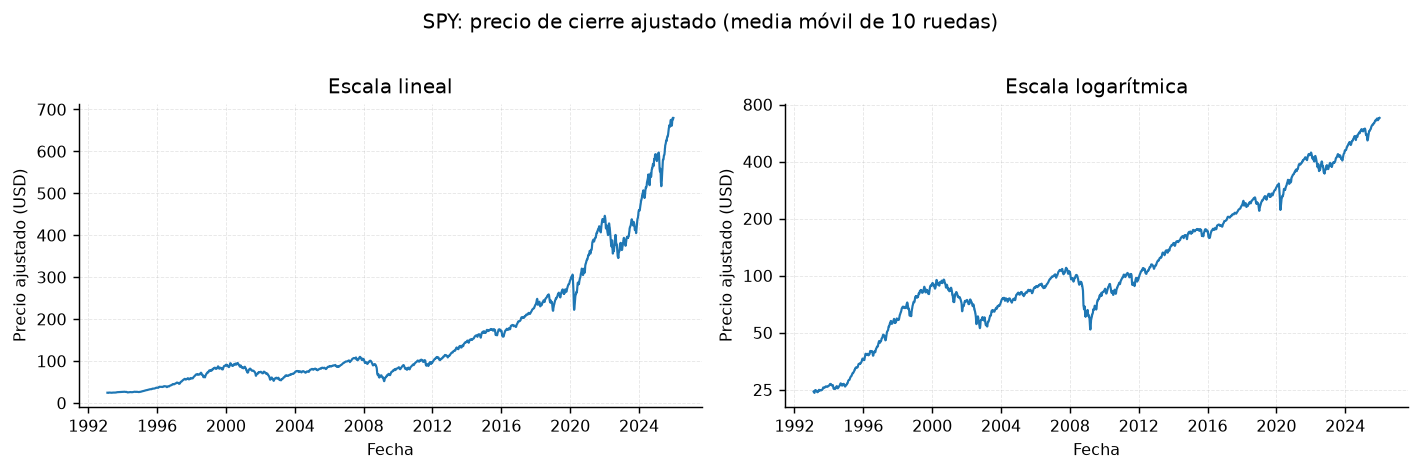

In [12]:
SMOOTH_WINDOW = 10
price_smooth = price.rolling(SMOOTH_WINDOW).mean()

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(11, 3.5))

ax_lin.plot(price_smooth.index, price_smooth.values, linewidth=1.2)
ax_lin.set_title("Escala lineal")
ax_lin.set_xlabel("Fecha")
ax_lin.set_ylabel("Precio ajustado (USD)")

ax_log.plot(price_smooth.index, price_smooth.values, linewidth=1.2)
ax_log.set_yscale("log")
ax_log.set_title("Escala logarítmica")
ax_log.set_xlabel("Fecha")
ax_log.set_ylabel("Precio ajustado (USD)")

# Ticks explícitos: en escala log el formato por defecto es notación científica
# y el eje menor satura de etiquetas.
ax_log.set_yticks([25, 50, 100, 200, 400, 800])
formatter = mticker.ScalarFormatter()
formatter.set_scientific(False)
ax_log.yaxis.set_major_formatter(formatter)
ax_log.yaxis.set_minor_locator(mticker.NullLocator())

fig.suptitle(f"{TICKER}: precio de cierre ajustado "
             f"(media móvil de {SMOOTH_WINDOW} ruedas)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Distribución de retornos

Sea $S_t$ el precio del activo al cierre del día $t$. El retorno logarítmico se define como

$$x_t = \log S_t - \log S_{t-1}.$$

Bajo el modelo de referencia (Bachelier–Osborne, movimiento browniano geométrico) los $x_t$ serían
i.i.d. gaussianos. La distribución empírica se aparta de esa hipótesis en dos direcciones:

- **Leptocurtosis:** exceso de curtosis $\kappa = \mathbb{E}[(x-\mu)^4]/\sigma^4 - 3 \gg 0$. Hay
  más masa en el centro y, sobre todo, en las colas: los eventos extremos son órdenes de magnitud
  más probables de lo que predice la gaussiana.
- **Asimetría negativa:** $\mathrm{skew} < 0$. Las caídas grandes son más frecuentes y abruptas
  que las subas de igual magnitud.

Para hacer visibles las colas se grafica la densidad en **escala logarítmica en $y$**: sobre ese eje
una gaussiana es una parábola invertida, y cualquier desvío de esa forma en los extremos es una
cola pesada. Se superpone además una $t$ de Student ajustada por máxima verosimilitud, cuyos grados
de libertad $\nu$ cuantifican el peso de las colas ($\nu \to \infty$ recupera la gaussiana; el momento
de orden $k$ existe sólo si $k < \nu$).

El número de bines se elige con la **regla de Freedman–Diaconis**, $h = 2\,\mathrm{IQR}\,n^{-1/3}$,
robusta frente a outliers (a diferencia de Scott, que usa el desvío estándar, inflado justamente
por las colas que queremos observar).

In [13]:
def freedman_diaconis_bins(x: np.ndarray) -> int:
    """Número de bines según la regla de Freedman-Diaconis: h = 2·IQR·n^(-1/3)."""
    x = np.asarray(x, dtype=float)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    h = 2.0 * iqr * len(x) ** (-1 / 3)
    return int(np.ceil((x.max() - x.min()) / h))


def describe_returns(x: np.ndarray, label: str) -> pd.Series:
    """Momentos muestrales y test de normalidad de Jarque-Bera."""
    x = np.asarray(x, dtype=float)
    jb_stat, jb_p = stats.jarque_bera(x)
    return pd.Series(
        {
            "n": len(x),
            "media": x.mean(),
            "desvío": x.std(ddof=1),
            "mediana": np.median(x),
            "mín": x.min(),
            "máx": x.max(),
            "asimetría": stats.skew(x),
            "curtosis (exceso)": stats.kurtosis(x, fisher=True),
            "Jarque-Bera": jb_stat,
            "p-valor JB": jb_p,
        },
        name=label,
    )


def plot_return_density(x: np.ndarray,
                        ax: plt.Axes,
                        xlabel: str,
                        fit_t: bool = True,
                        log_y: bool = True,
                        xlim: float = 0.10,
                        bins: int = 250) -> dict:
    """Histograma de densidad con los ajustes gaussiano y t-Student superpuestos.

    Devuelve los parámetros ajustados para reportarlos aparte.
    """
    x = np.asarray(x, dtype=float)
    grid = np.linspace(-xlim, xlim, 500)

    mu, sigma = stats.norm.fit(x)
    params = {"mu": mu, "sigma": sigma}

    ax.hist(x, bins=bins, density=True, alpha=0.6,
            color="skyblue", label="Histograma", zorder=1)
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), "r-",
            linewidth=1.8, label="Normal", zorder=4)

    if fit_t:
        df_t, loc_t, scale_t = stats.t.fit(x)
        params.update({"df": df_t, "loc": loc_t, "scale": scale_t})
        ax.plot(grid, stats.t.pdf(grid, df_t, loc_t, scale_t),
                color="darkorange", linestyle="--", linewidth=1.8,
                label=rf"t-Student ($\nu$={df_t:.1f})", zorder=3)

    if log_y:
        ax.set_yscale("log")
        ax.set_ylim(bottom=1e-3)
    ax.set_xlim(-xlim, xlim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Densidad")
    ax.legend(loc="best")
    return params

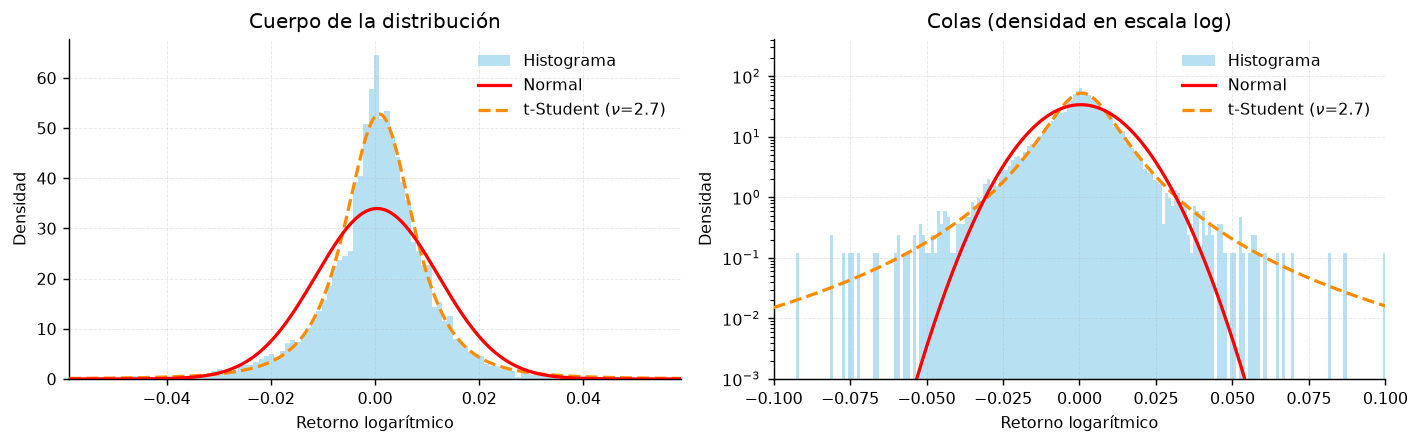

Bines sugeridos (Freedman-Diaconis): 249
Normal    : μ=0.00040, σ=0.01174
t-Student : ν=2.74, loc=0.00082, scale=0.00691


In [14]:
# Panel izquierdo: escala lineal, útil para ver el cuerpo de la distribución.
# Panel derecho : escala logarítmica, donde las colas pesadas quedan expuestas.
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(11, 3.5))

plot_return_density(log_ret.values, ax_lin, "Retorno logarítmico",
                    fit_t=True, log_y=False,
                    xlim=5 * log_ret.std())
params = plot_return_density(log_ret.values, ax_log, "Retorno logarítmico",
                             fit_t=True, log_y=True, xlim=0.10)

ax_lin.set_title("Cuerpo de la distribución")
ax_log.set_title("Colas (densidad en escala log)")
plt.tight_layout()
plt.show()

print(f"Bines sugeridos (Freedman-Diaconis): {freedman_diaconis_bins(log_ret.values)}")
print(f"Normal    : μ={params['mu']:.5f}, σ={params['sigma']:.5f}")
print(f"t-Student : ν={params['df']:.2f}, loc={params['loc']:.5f}, scale={params['scale']:.5f}")

### 4.1 Retornos simples vs. logarítmicos

Comparación de los momentos bajo las dos definiciones. La asimetría y la curtosis son
cualitativamente idénticas: la elección de la definición no genera el hecho estilizado, sólo lo
reexpresa. El test de Jarque–Bera rechaza la normalidad en ambos casos con un margen enorme.

In [15]:
moments = pd.concat(
    [
        describe_returns(simple_ret.values, "Retorno simple"),
        describe_returns(log_ret.values, "Retorno logarítmico"),
    ],
    axis=1,
)
moments.map(lambda v: f"{v:.4g}")

,Retorno simple,Retorno logarítmico
n,8287,8287
media,0.0004717,0.0004027
desvío,0.01174,0.01174
mediana,0.0006821,0.0006819
mín,-0.1094,-0.1159
máx,0.1452,0.1356
asimetría,-0.0106,-0.2485
curtosis (exceso),11.83,11.4
Jarque-Bera,4.833e+04,4.494e+04
p-valor JB,0,0


## 5. Momentos con incertidumbre: *moving block bootstrap*

Reportar una curtosis puntual sin barras de error es engañoso: se trata de un estimador de momento
de orden 4, dominado por un puñado de observaciones extremas, y por lo tanto de varianza muy alta.

El bootstrap i.i.d. clásico tampoco sirve acá, porque **destruye la dependencia temporal**: al
remuestrear observaciones sueltas se rompe el clustering de volatilidad (Sección 6) y los intervalos
resultan artificialmente angostos. Se usa entonces un *moving block bootstrap*, que remuestrea
bloques contiguos de longitud $b$ y preserva la estructura de dependencia dentro de cada bloque.

La elección $b \approx 10$ días hábiles es un compromiso: suficientemente largo para contener un
episodio típico de volatilidad, suficientemente corto para que el número de bloques efectivos
$T/b$ mantenga variabilidad en las réplicas.

In [16]:
def block_bootstrap_ci(x: np.ndarray,
                       func,
                       block_size: int = BLOCK_SIZE,
                       reps: int = N_BOOT,
                       alpha: float = ALPHA) -> tuple[np.ndarray, np.ndarray]:
    """Estimación puntual e IC percentil vía moving block bootstrap.

    Returns
    -------
    (estimación, ci) donde ci tiene forma (2, k): fila 0 = límite inferior,
    fila 1 = límite superior.
    """
    x = np.asarray(x, dtype=float)
    bs = MovingBlockBootstrap(block_size, x=x)
    ci = bs.conf_int(func, reps=reps, method="percentile", size=1 - alpha)
    return np.atleast_1d(func(x)), np.asarray(ci)


def excess_kurtosis(x):
    """Exceso de curtosis (fisher=True ⇒ 0 para una gaussiana)."""
    return np.array([stats.kurtosis(x, fisher=True)])


def annualized_stats(x):
    """[media anualizada, volatilidad anualizada] a partir de retornos diarios."""
    return np.array([np.mean(x) * TRADING_DAYS,
                     np.std(x, ddof=1) * np.sqrt(TRADING_DAYS)])


r = log_ret.values

k_hat, k_ci = block_bootstrap_ci(r, excess_kurtosis)
ann_hat, ann_ci = block_bootstrap_ci(r, annualized_stats, reps=2_000)

print(f"Exceso de curtosis      : {k_hat[0]:7.2f}   "
      f"(IC {1-ALPHA:.0%}: [{k_ci[0, 0]:.2f}, {k_ci[1, 0]:.2f}])")
print(f"Media anualizada        : {ann_hat[0]:7.2%}   "
      f"(IC {1-ALPHA:.0%}: [{ann_ci[0, 0]:.2%}, {ann_ci[1, 0]:.2%}])")
print(f"Volatilidad anualizada  : {ann_hat[1]:7.2%}   "
      f"(IC {1-ALPHA:.0%}: [{ann_ci[0, 1]:.2%}, {ann_ci[1, 1]:.2%}])")

Exceso de curtosis      :   11.40   (IC 95%: [6.24, 16.12])
Media anualizada        :  10.15%   (IC 95%: [4.45%, 15.90%])
Volatilidad anualizada  :  18.64%   (IC 95%: [17.34%, 20.14%])


## 6. Autocorrelación: retornos vs. retornos al cuadrado

El par de resultados más citado sobre series financieras diarias:

1. $\rho(x_t, x_{t-k}) \approx 0$ para $k \ge 1$ — no hay estructura **lineal** predecible, en línea
   con la forma débil de la hipótesis de mercados eficientes.
2. $\rho(x_t^2, x_{t-k}^2) > 0$ y con decaimiento lento — la **magnitud** de los retornos sí es
   fuertemente predecible.

Es decir: los retornos son *no correlacionados* pero no *independientes*.

**Sobre las bandas de confianza.** Las bandas estándar $\pm 1.96/\sqrt{T}$ suponen ruido blanco
homocedástico. Bajo heterocedasticidad condicional —exactamente lo que caracteriza a esta serie—
subestiman la varianza de $\hat\rho_k$ y producen rechazos espurios. Se usa entonces la corrección
robusta de Diebold (1986),

$$\widehat{\mathrm{Var}}(\hat\rho_k) \;=\; \frac{1}{T}\,
\frac{\mathbb{E}\!\left[r_t^2\, r_{t-k}^2\right]}{\gamma_0^2},$$

que es la que se grafica en el panel de los retornos. Para los retornos al cuadrado alcanza con la
banda de ruido blanco de Bartlett $\\pm z_{1-\\alpha/2}/\\sqrt{T}$: la señal ahí es tan grande que
cualquier corrección de segundo orden resulta irrelevante.

In [17]:
def heteroskedastic_robust_acf(returns: np.ndarray,
                               max_lags: int = MAX_LAGS,
                               alpha: float = ALPHA):
    """ACF muestral con bandas de confianza robustas a heterocedasticidad.

    Implementa la corrección de Diebold (1986), válida bajo dependencia en la
    varianza condicional (ARCH/GARCH), donde las bandas ±z/√T no lo son.

    Returns
    -------
    (acf, ci_bound) : arrays de largo max_lags+1; la banda es simétrica ±ci_bound.
    """
    r = np.asarray(returns, dtype=float)
    r = r - r.mean()
    T = len(r)
    gamma_0 = np.mean(r ** 2)
    z = stats.norm.ppf(1 - alpha / 2)

    acf_vals = np.zeros(max_lags + 1)
    ci_bound = np.zeros(max_lags + 1)
    acf_vals[0] = 1.0

    for k in range(1, max_lags + 1):
        gamma_k = np.mean(r[k:] * r[:-k])
        acf_vals[k] = gamma_k / gamma_0

        # Varianza robusta: E[r_t² r_{t-k}²] / γ₀² en lugar de 1 (Diebold, 1986).
        v_k = np.mean((r[k:] ** 2) * (r[:-k] ** 2)) / gamma_0 ** 2
        ci_bound[k] = z * np.sqrt(v_k / T)

    return acf_vals, ci_bound


def sample_acf(x: np.ndarray, max_lags: int = MAX_LAGS) -> np.ndarray:
    """ACF muestral simple (sin bandas), usada para los retornos al cuadrado."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    gamma_0 = np.mean(x ** 2)
    return np.array([1.0] + [np.mean(x[k:] * x[:-k]) / gamma_0
                             for k in range(1, max_lags + 1)])

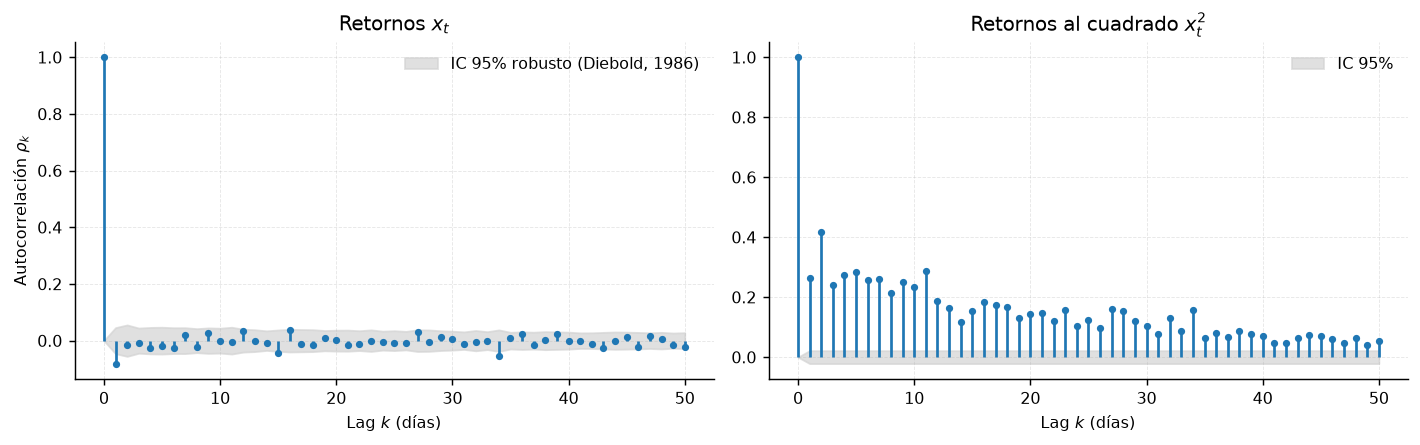

Lags 1-50 fuera de la banda robusta — retornos      : 3/50
Lags 1-50 fuera de la banda        — retornos²     : 50/50


In [18]:
fig, (ax_r, ax_r2) = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True)

# --- Retornos: ACF con bandas robustas a heterocedasticidad ---
acf_r, ci_r = heteroskedastic_robust_acf(r, max_lags=MAX_LAGS, alpha=ALPHA)
markerline, *_ = ax_r.stem(np.arange(len(acf_r)), acf_r, basefmt=" ")
plt.setp(markerline, markersize=3)
ax_r.fill_between(np.arange(len(ci_r)), -ci_r, ci_r,
                  color="lightgray", alpha=0.7,
                  label=f"IC {1-ALPHA:.0%} robusto (Diebold, 1986)")
ax_r.set_title(r"Retornos $x_t$")
ax_r.set_xlabel("Lag $k$ (días)")
ax_r.set_ylabel(r"Autocorrelación $\rho_k$")
ax_r.legend(loc="upper right")

# --- Retornos al cuadrado: proxy de volatilidad ---
acf_sq = sample_acf(r ** 2, max_lags=MAX_LAGS)
# Banda de ruido blanco de Bartlett: ±z/√T, suficiente acá porque la señal
# es de un orden de magnitud mayor que cualquier corrección de segundo orden.
margin = np.full_like(acf_sq, stats.norm.ppf(1 - ALPHA / 2) / np.sqrt(len(r)))
margin[0] = 0.0
markerline, *_ = ax_r2.stem(np.arange(len(acf_sq)), acf_sq, basefmt=" ")
plt.setp(markerline, markersize=3)
ax_r2.fill_between(np.arange(len(acf_sq)), -margin, margin,
                   color="lightgray", alpha=0.7, label=f"IC {1-ALPHA:.0%}")
ax_r2.set_title(r"Retornos al cuadrado $x_t^2$")
ax_r2.set_xlabel("Lag $k$ (días)")
ax_r2.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"Lags 1-{MAX_LAGS} fuera de la banda robusta — retornos      : "
      f"{np.sum(np.abs(acf_r[1:]) > ci_r[1:])}/{MAX_LAGS}")
print(f"Lags 1-{MAX_LAGS} fuera de la banda        — retornos²     : "
      f"{np.sum(np.abs(acf_sq[1:]) > margin[1:])}/{MAX_LAGS}")

## 7. Clustering de volatilidad y regímenes

La autocorrelación de $x_t^2$ tiene una contrapartida visual directa: los períodos de alta y baja
volatilidad se agrupan. Se estima la volatilidad condicional con un promedio móvil exponencial
(EWMA, convención RiskMetrics $\lambda = 0.94$),

$$\sigma_t^2 = \lambda\,\sigma_{t-1}^2 + (1-\lambda)\,x_{t-1}^2,$$

que es el caso límite de un GARCH(1,1) integrado sin término constante. Se elige EWMA por sobre un
GARCH ajustado por máxima verosimilitud porque no requiere optimización numérica y no introduce
parámetros estimados en un análisis que es puramente descriptivo.

Se sombrean los períodos en que $\sigma_t$ supera su percentil 90: 1998, 2000–2002, 2008–2009, 2020
y 2022 aparecen como los regímenes de tensión, y cada uno coincide con una caída significativa del
precio — la manifestación del *efecto apalancamiento* (correlación negativa entre retorno y
volatilidad futura).

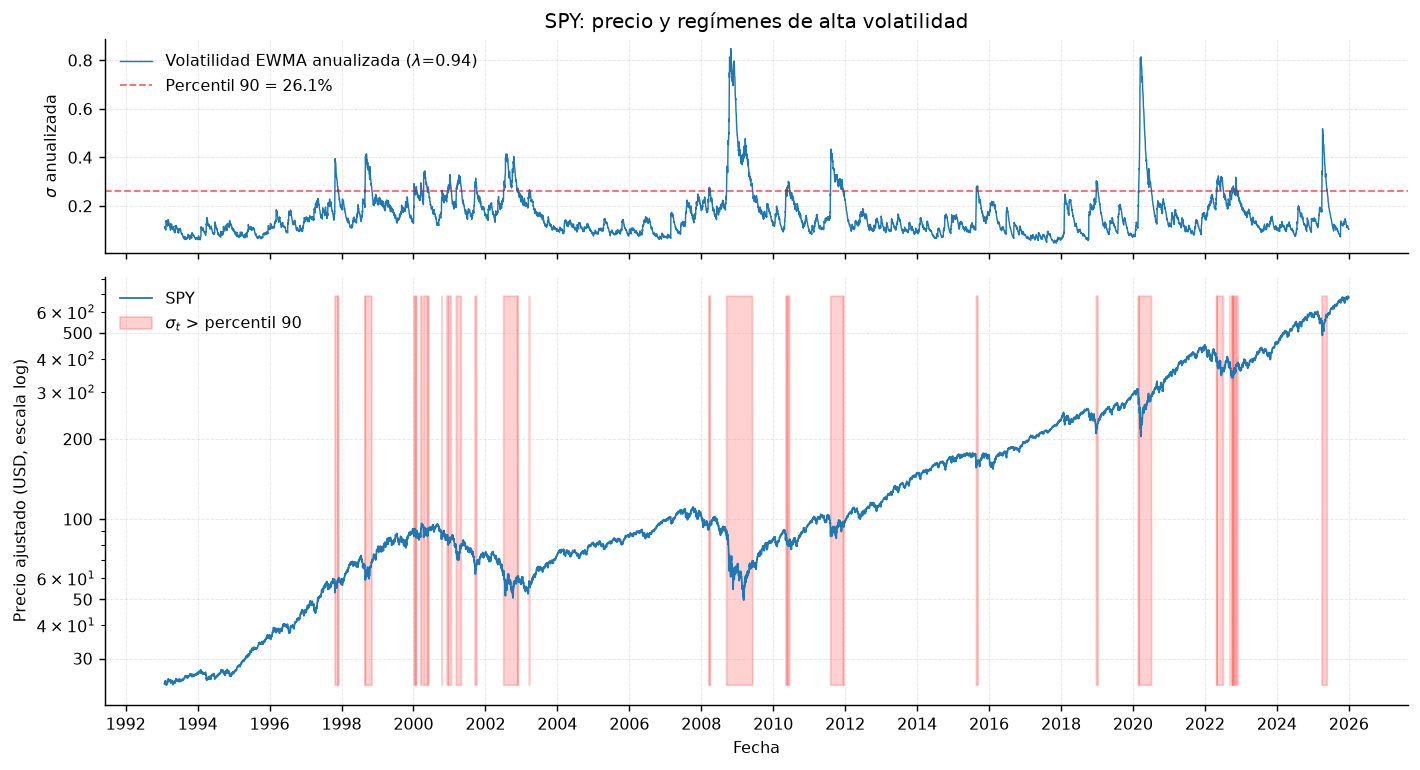

In [19]:
ewma_var  = log_ret.pow(2).ewm(alpha=1 - LAMBDA_EWMA, adjust=False).mean()
volatility = np.sqrt(ewma_var) * np.sqrt(TRADING_DAYS)   # anualizada

vol_q90 = volatility.quantile(0.90)
high_vol_mask = (volatility > vol_q90).reindex(price.index).fillna(False)

fig, (ax_vol, ax_price) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [1, 2]}
)

ax_vol.plot(volatility.index, volatility.values, linewidth=0.8,
            label=rf"Volatilidad EWMA anualizada ($\lambda$={LAMBDA_EWMA})")
ax_vol.axhline(vol_q90, linestyle="--", color="red", alpha=0.6, linewidth=1.0,
               label=f"Percentil 90 = {vol_q90:.1%}")
ax_vol.set_ylabel(r"$\sigma$ anualizada")
ax_vol.set_title(f"{TICKER}: precio y regímenes de alta volatilidad")
ax_vol.legend(loc="upper left")

ax_price.semilogy(price.index, price.values, linewidth=1.0, label=TICKER)
ax_price.fill_between(price.index, price.min(), price.max(),
                      where=high_vol_mask.values, color="red", alpha=0.18,
                      interpolate=True, label=r"$\sigma_t$ > percentil 90")
ax_price.set_ylabel("Precio ajustado (USD, escala log)")
ax_price.set_xlabel("Fecha")
ax_price.legend(loc="upper left")

ax_price.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax_price.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_price.set_yticks([30, 50, 100, 200, 500])
formatter = mticker.ScalarFormatter()
formatter.set_scientific(False)
ax_price.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### 7.1 Bandas incondicionales: por qué $\sigma$ constante no alcanza

Graficar la serie de retornos contra bandas $\pm k\sigma$ calculadas sobre **toda** la muestra
muestra el problema desde otro ángulo: las excursiones fuera de la banda no están repartidas de
manera homogénea en el tiempo, sino concentradas en los mismos episodios de la sección anterior.
Además, la fracción observada fuera de $\pm 2\sigma$ excede a la que predice una gaussiana, que es
la traducción cuantitativa de las colas pesadas de la Sección 4.

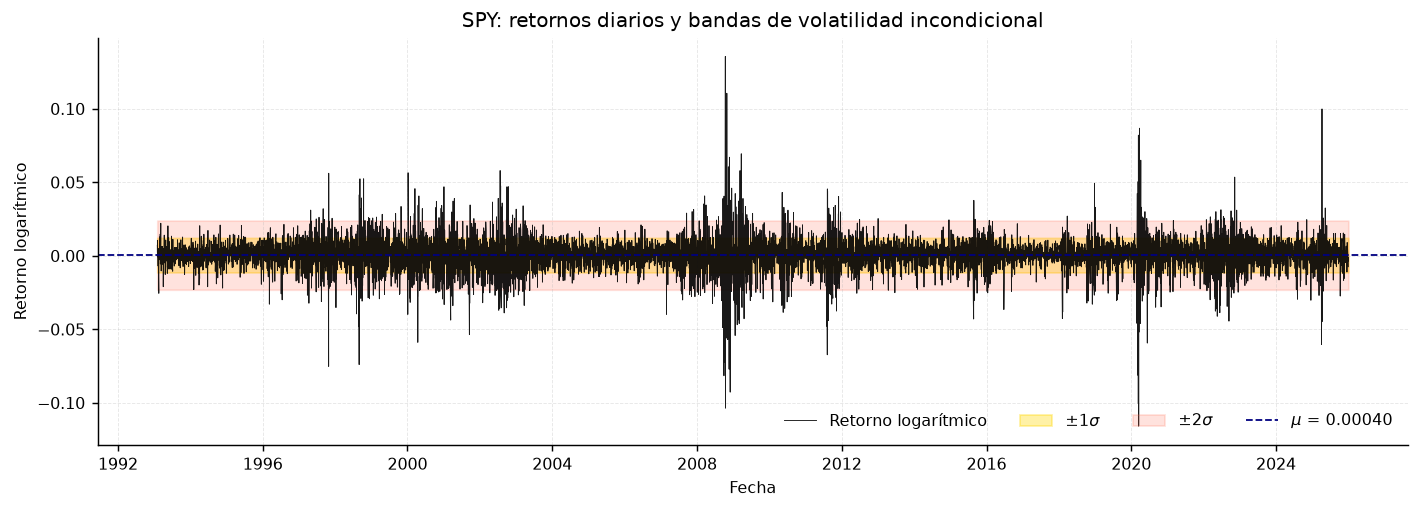

|z| > 1σ   empírico: 20.7554%   gaussiano: 31.7311%   ratio: x   0.7
|z| > 2σ   empírico: 4.7786%   gaussiano: 4.5500%   ratio: x   1.1
|z| > 3σ   empírico: 1.5084%   gaussiano: 0.2700%   ratio: x   5.6
|z| > 5σ   empírico: 0.2896%   gaussiano: 0.0001%   ratio: x5051.6


In [20]:
mu, sigma = log_ret.mean(), log_ret.std()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(log_ret.index, log_ret.values, color="black", lw=0.5, alpha=0.9,
        label="Retorno logarítmico")
ax.fill_between(log_ret.index, mu - sigma, mu + sigma,
                color="gold", alpha=0.35, label=r"$\pm 1\sigma$")
ax.fill_between(log_ret.index, mu - 2 * sigma, mu + 2 * sigma,
                color="tomato", alpha=0.18, label=r"$\pm 2\sigma$")
ax.axhline(mu, color="navy", ls="--", lw=1.0, label=rf"$\mu$ = {mu:.5f}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Retorno logarítmico")
ax.set_title(f"{TICKER}: retornos diarios y bandas de volatilidad incondicional")
ax.legend(loc="lower right", ncol=4)
plt.tight_layout()
plt.show()

# Fracción observada fuera de las bandas vs. la predicción gaussiana.
z_scores = ((log_ret - mu) / sigma).abs()
for k in (1, 2, 3, 5):
    empirical = (z_scores > k).mean()
    gaussian  = 2 * stats.norm.sf(k)
    print(f"|z| > {k}σ   empírico: {empirical:7.4%}   gaussiano: {gaussian:7.4%}   "
          f"ratio: x{empirical / gaussian:6.1f}")

## 8. Resumen

La tabla siguiente se calcula a partir de los objetos ya construidos: no hay números escritos
a mano en el texto, de modo que cambiar `TICKER` o la ventana temporal en la Sección 1 regenera
el resumen completo.

In [21]:
summary = pd.DataFrame(
    [
        ("Observaciones",             f"{len(log_ret):,}",                      "—"),
        ("Media anualizada",          f"{ann_hat[0]:.2%}",                      "—"),
        ("Volatilidad anualizada",    f"{ann_hat[1]:.2%}",                      "—"),
        ("Asimetría",                 f"{stats.skew(r):.2f}",                   "0"),
        ("Exceso de curtosis",        f"{k_hat[0]:.2f}",                        "0"),
        ("Grados de libertad (t)",    f"{params['df']:.1f}",                    "∞"),
        ("Jarque-Bera (p-valor)",     f"{stats.jarque_bera(r)[1]:.1e}",         "> 0.05"),
        ("Lags significativos en ACF(x)",   f"{np.sum(np.abs(acf_r[1:]) > ci_r[1:])}/{MAX_LAGS}",    f"~{int(ALPHA*MAX_LAGS)}/{MAX_LAGS}"),
        ("Lags significativos en ACF(x²)",  f"{np.sum(np.abs(acf_sq[1:]) > margin[1:])}/{MAX_LAGS}", f"~{int(ALPHA*MAX_LAGS)}/{MAX_LAGS}"),
        ("Fracción |z| > 3σ",         f"{(z_scores > 3).mean():.3%}",           f"{2*stats.norm.sf(3):.3%}"),
    ],
    columns=["Métrica", "SPY (observado)", "Bajo normalidad i.i.d."],
)
summary

,Métrica,SPY (observado),Bajo normalidad i.i.d.
0,Observaciones,"8,287",—
1,Media anualizada,10.15%,—
2,Volatilidad anualizada,18.64%,—
3,Asimetría,-0.25,0
4,Exceso de curtosis,11.40,0
5,Grados de libertad (t),2.7,∞
6,Jarque-Bera (p-valor),0.0e+00,> 0.05
7,Lags significativos en ACF(x),3/50,~2/50
8,Lags significativos en ACF(x²),50/50,~2/50
9,Fracción |z| > 3σ,1.508%,0.270%


### Conclusiones

1. El precio crece de forma aproximadamente exponencial, pero con drawdowns que la escala lineal
   oculta.
2. Los retornos diarios **no son gaussianos**: el exceso de curtosis es de un orden de magnitud
   incompatible con la normalidad incluso considerando la incertidumbre del bootstrap por bloques,
   y la $t$ de Student ajustada indica colas con pocos momentos finitos.
3. La asimetría negativa es sistemática: las caídas son más abruptas que las subas.
4. No hay autocorrelación lineal explotable en los retornos, pero sí una dependencia fuerte y
   persistente en su magnitud. Cualquier modelo razonable debe ser **no correlacionado pero
   dependiente**: ARCH/GARCH, volatilidad estocástica, o modelos multifractales.
5. La volatilidad se agrupa en regímenes identificables, y los de alta volatilidad coinciden con
   caídas de precio (efecto apalancamiento).

En conjunto, esto descarta el movimiento browniano geométrico con $\\sigma$ constante como modelo
de trabajo y motiva el marco de volatilidad condicional que se desarrolla en el resto del proyecto.

---

### Referencias

- Mandelbrot, B. (1963). *The Variation of Certain Speculative Prices*. Journal of Business, 36(4).
- Fama, E. (1965). *The Behavior of Stock-Market Prices*. Journal of Business, 38(1).
- Diebold, F. X. (1986). *Testing for Serial Correlation in the Presence of ARCH*. Proceedings of the ASA.
- Bollerslev, T. (1986). *Generalized Autoregressive Conditional Heteroskedasticity*. Journal of Econometrics, 31(3).
- Künsch, H. R. (1989). *The Jackknife and the Bootstrap for General Stationary Observations*. Annals of Statistics, 17(3).
- Cont, R. (2001). *Empirical properties of asset returns: stylized facts and statistical issues*. Quantitative Finance, 1(2).
- J.P. Morgan / Reuters (1996). *RiskMetrics — Technical Document*, 4th ed.